In [124]:
import sys
from pathlib import Path
from typing import Dict, Iterable, List, Optional
import pandas as pd
from torch.utils.data import Dataset
import torch
import numpy as np
from src.utils.data_utils import triple_barrier_label, min_max_label, split_scale, CryptoDataset
from src.models.DL_models import *
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [125]:
# Update the path below to point to the desired preprocessed parquet file.
default_parquet = Path("data/processed/BTC_USDT_15m_futures.parquet")

df = pd.read_parquet(default_parquet)

ku = 3
kd = 1
hold = 48
df_labeled = triple_barrier_label(df, ku=ku, kd=kd, hold=hold, debug=False)
# df_labeled = min_max_label(df, horizon=48)
df_labeled

,open,high,low,close,volume,funding_rate,ema_20,ema_50,ema_200,macd,...,dayofweek_sin,dayofweek_cos,session_Asia,session_Frankfurt,session_London,session_NewYork,session_OffHours,pda_Discount,pda_Premium,y
0,6909.83,6909.83,6872.78,6884.74,7.886164,-0.000017,-2.814693,-5.059633,-11.835218,-1.076070,...,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2
1,6884.72,6900.84,6863.44,6900.52,7.778294,-0.000017,-1.805547,-3.971036,-10.479156,-1.060945,...,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2
2,6900.46,6943.00,6900.46,6938.92,7.901142,-0.000017,-0.119535,-2.089074,-8.229299,-0.890728,...,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2
3,6938.91,6960.00,6937.61,6950.01,7.711550,-0.000017,0.304085,-1.580837,-7.744898,-0.762934,...,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2
4,6950.01,6959.00,6941.27,6952.58,6.956475,-0.000017,0.378111,-1.445149,-7.712092,-0.654092,...,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204896,102944.00,103045.50,102766.30,102766.30,6.565908,0.000079,-1.336382,-1.672617,-2.578491,-0.450283,...,0.433884,-0.900969,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1
204897,102766.40,102913.60,102611.50,102828.80,7.409141,0.000079,-1.027544,-1.414717,-2.356053,-0.484238,...,0.433884,-0.900969,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1
204898,102828.80,103061.30,102813.70,102987.40,6.586507,0.000079,-0.470834,-0.877282,-1.849264,-0.470352,...,0.433884,-0.900969,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1
204899,102987.30,103250.00,102975.90,103070.00,7.158573,0.000079,-0.181389,-0.585888,-1.572842,-0.430040,...,0.433884,-0.900969,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1


In [126]:
# target = ['y_high', 'y_low']
target = ['y']
window_size = 96
df_labeled.describe()
# dataset = CryptoDataset(df_w, window_size=window_size,
# target=target)

# print(dataset[0])
# print(dataset[0][0].shape)  # Features shape

,open,high,low,close,volume,funding_rate,ema_20,ema_50,ema_200,macd,...,dayofweek_sin,dayofweek_cos,session_Asia,session_Frankfurt,session_London,session_NewYork,session_OffHours,pda_Discount,pda_Premium,y
count,204901.000000,204901.000000,204901.000000,204901.000000,204901.000000,204901.000000,204901.000000,204901.000000,204901.000000,204901.000000,...,204901.000000,204901.000000,204901.000000,204901.000000,204901.000000,204901.000000,204901.000000,204901.000000,204901.000000,204901.000000
mean,46039.994719,46131.525071,45946.359089,46040.462553,7.706221,0.000119,0.056962,0.143769,0.466982,0.042872,...,-0.000095,0.000259,0.250057,0.041679,0.291673,0.291614,0.124977,0.456733,0.543267,1.208105
std,30960.653003,31004.453427,30915.888219,30960.788930,0.933605,0.000221,1.203793,1.927497,4.230074,0.620998,...,0.707172,0.707045,0.433047,0.199854,0.454533,0.454507,0.330694,0.498126,0.498126,0.473830
min,3757.750000,4155.210000,3621.810000,3761.100000,0.000000,-0.003000,-8.479107,-9.737628,-17.607395,-2.486042,...,-0.974928,-0.900969,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21481.400000,21537.600000,21431.600000,21481.500000,7.065132,0.000034,-0.666020,-1.116114,-2.533945,-0.363817,...,-0.781831,-0.900969,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,38798.300000,38920.410000,38700.000000,38798.400000,7.660139,0.000100,0.057331,0.122566,0.412341,0.034844,...,0.000000,-0.222521,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
75%,62973.620000,63095.000000,62850.100000,62974.280000,8.306192,0.000100,0.757531,1.358318,3.396834,0.432625,...,0.781831,0.623490,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,125986.100000,126208.500000,125583.000000,125986.000000,12.053108,0.003000,8.440986,9.798581,21.746966,2.565215,...,0.974928,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000


In [127]:
df_train, df_val, df_test, scaler = split_scale(
    df_labeled, target_cols=target, scale=True)

df_train.describe()

# print(df_train[target].value_counts())

[INFO] Using StandardScaler, scaling = True
[INFO] Total features: 64 | Scaled: 41 | Excluded: ['open', 'high', 'low', 'close', 'atr_14']
[OK] Standard scaling applied to 41 columns.
[OK] Split complete → Train: 143430, Val: 30735, Test: 30736


,open,high,low,close,volume,funding_rate,ema_20,ema_50,ema_200,macd,...,dayofweek_sin,dayofweek_cos,session_Asia,session_Frankfurt,session_London,session_NewYork,session_OffHours,pda_Discount,pda_Premium,y
count,143430.000000,143430.000000,143430.000000,143430.000000,143430.000000,143430.000000,143430.000000,143430.000000,143430.000000,143430.000000,...,143430.000000,143430.000000,143430.000000,143430.000000,143430.000000,143430.000000,143430.000000,143430.000000,143430.000000,143430.000000
mean,29215.837967,29286.838251,29143.167834,29216.084689,0.071042,0.020695,-0.005598,-0.009629,-0.021525,-0.008406,...,-0.001509,0.000419,0.250031,0.041665,0.291654,0.291654,0.124995,0.460266,0.539734,1.207237
std,15074.695192,15118.423823,15029.865398,15074.621896,0.987531,1.073744,0.993758,0.994904,0.994428,0.994413,...,1.000226,0.999780,0.433032,0.199823,0.454526,0.454526,0.330714,0.498420,0.498420,0.471781
min,3757.750000,4155.210000,3621.810000,3761.100000,-8.733885,-13.210039,-7.190468,-5.191275,-4.293054,-4.135378,...,-1.378341,-1.273350,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17131.057500,17148.325000,17104.390000,17131.125000,-0.614271,-0.387017,-0.596960,-0.652893,-0.710643,-0.650679,...,-1.105238,-1.273350,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,27697.850000,27756.950000,27651.650000,27698.250000,0.003432,-0.132985,-0.009760,-0.026686,-0.031827,-0.025485,...,0.000535,-0.313963,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
75%,40914.072500,41052.950000,40782.675000,40915.050000,0.694509,-0.132985,0.561445,0.607318,0.657431,0.599443,...,1.106308,0.882373,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,68806.620000,69198.700000,68541.250000,68805.500000,4.726455,12.100388,7.056412,5.066845,5.047264,4.119617,...,1.379412,1.414793,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000


In [128]:
train_data = CryptoDataset(
    df_train.drop(columns=['open', 'high', 'low', 'close', 'atr_14']), window_size=window_size, target=target)
val_data = CryptoDataset(df_val.drop(columns=[
                         'open', 'high', 'low', 'close', 'atr_14']), window_size=window_size, target=target)
test_data = CryptoDataset(df_test.drop(columns=[
                          'open', 'high', 'low', 'close', 'atr_14']), window_size=window_size, target=target)

In [129]:
df_val[['open', 'high', 'low', 'close', 'atr_14']+target]

,open,high,low,close,atr_14,y
0,42522.4,42598.0,42522.4,42559.4,108.273700,2
1,42559.5,42597.4,42547.6,42572.1,104.097007,2
2,42572.1,42722.0,42569.9,42708.0,107.525792,2
3,42707.9,42713.3,42650.1,42669.0,104.359664,2
4,42669.0,42826.0,42662.0,42749.4,108.619688,1
...,...,...,...,...,...,...
30730,97871.9,98647.5,97871.9,98644.1,312.986867,1
30731,98644.0,98785.5,98376.9,98749.9,319.816377,1
30732,98750.0,98750.0,98267.1,98367.4,331.465207,2
30733,98367.3,98550.0,98282.9,98487.6,326.867692,2


In [130]:
# pass a flat list of column names to drop (not a nested list)
n_features = df_train.drop(columns=['open', 'high', 'low', 'close', 'atr_14'] + target).shape[1]

input_size = n_features
input_size

59

In [131]:
df_train['y'].value_counts(normalize=True)

y
1    0.734477
2    0.236380
0    0.029143
Name: proportion, dtype: float64

In [132]:
lr = 1e-4

In [133]:
base_name = f'btc_all-feat_2020-2025_tb_{ku}-{kd}'


In [134]:
model_path = "artifacts/lstm_" + base_name + ".pt"
loss_plot_path = "artifacts/lstm_" + base_name + ".png"

model = LSTMClassifier(input_size=input_size, dropout=0.3)
output = model.train(train_data, val_data, model_path=model_path, loss_plot_path=loss_plot_path, batch_size=128, lr=lr, weights=None)

print("Best val loss: ",output['best_val_loss'])

prediction = model.predict(val_data)
print(prediction[['prediction', 'true']].value_counts())

confusion_matrix(prediction['true'], prediction['prediction'])

Epoch 1/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Epoch 2/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Epoch 3/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Epoch 4/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Epoch 5/50:   0%|          | 0/1120 [00:00<?, ?it/s]

...

Epoch 9/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Epoch 10/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Epoch 11/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Best val loss:  0.5376495634606862
prediction  true
1           1       19820
            2        3832
2           2        3560
            1        2177
1           0         746
0           2         137
2           0         133
0           1         119
            0         116
Name: count, dtype: int64


array([[  116,   746,   133],
       [  119, 19820,  2177],
       [  137,  3832,  3560]], dtype=int64)

In [135]:
model_path = "artifacts/bilstm_" + base_name + ".pt"
loss_plot_path = "artifacts/bilstm_" + base_name + ".png"

model_bi = BiLSTMClassifier(input_size=input_size, dropout=0.3)
output_bi = model_bi.train(train_data, val_data, model_path=model_path,
                     loss_plot_path=loss_plot_path, batch_size=128, lr=lr)

print("Best val loss: ", output_bi['best_val_loss'])

prediction_bi = model_bi.predict(val_data)
print(prediction_bi[['prediction', 'true']].value_counts())

confusion_matrix(prediction_bi['true'], prediction_bi['prediction'])

Epoch 1/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Epoch 2/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Epoch 3/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Epoch 4/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Epoch 5/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Epoch 6/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Epoch 7/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Epoch 8/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Best val loss:  0.5362747198607841
prediction  true
1           1       19687
2           2        3848
1           2        3580
2           1        2301
1           0         745
2           0         166
0           1         128
            2         101
            0          84
Name: count, dtype: int64


array([[   84,   745,   166],
       [  128, 19687,  2301],
       [  101,  3580,  3848]], dtype=int64)

In [136]:
model_path = "artifacts/gru_" + base_name + ".pt"
loss_plot_path = "artifacts/gru_" + base_name + ".png"

model_gru = GRUClassifier(input_size=input_size, dropout=0.3)
output_gru = model_gru.train(train_data, val_data, model_path=model_path,
                           loss_plot_path=loss_plot_path, batch_size=128, lr=lr)

print("Best val loss: ", output_gru['best_val_loss'])

prediction_gru = model_gru.predict(val_data)
print(prediction_gru[['prediction', 'true']].value_counts())

confusion_matrix(prediction_gru['true'], prediction_gru['prediction'])

Epoch 1/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Epoch 2/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Epoch 3/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Epoch 4/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Epoch 5/50:   0%|          | 0/1120 [00:00<?, ?it/s]

...

Epoch 12/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Epoch 13/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Epoch 14/50:   0%|          | 0/1120 [00:00<?, ?it/s]

Best val loss:  0.5116523342095218
prediction  true
1           1       19747
2           2        4111
1           2        3329
2           1        2220
1           0         712
2           0         161
0           1         149
            0         122
            2          89
Name: count, dtype: int64


array([[  122,   712,   161],
       [  149, 19747,  2220],
       [   89,  3329,  4111]], dtype=int64)

In [137]:
def triple_barrier_metrics(cm: np.ndarray):
    """
    cm: 3x3 confusion matrix (rows=true: 0=expiry,1=SL,2=TP; cols=pred)
    Returns precision/recall/F1 for TP (2) and SL (1), plus macro over {TP,SL}.
    """
    cm = np.asarray(cm, dtype=np.float64)
    if cm.shape != (3, 3):
        raise ValueError(
            "cm must be 3x3 with classes [0,1,2] = [expiry, SL, TP].")

    def prf(k: int):
        tp = cm[k, k]
        fp = cm[:, k].sum() - tp
        fn = cm[k, :].sum() - tp
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0
        return prec, rec, f1

    # Class 2 = TP-first, Class 1 = SL-first
    p_tp, r_tp, f1_tp = prf(2)
    p_sl, r_sl, f1_sl = prf(1)

    macro_precision = (p_tp + p_sl) / 2
    macro_recall = (r_tp + r_sl) / 2
    macro_f1 = (f1_tp + f1_sl) / 2

    return {
        "tp_precision": p_tp, "tp_recall": r_tp, "tp_f1": f1_tp,
        "sl_precision": p_sl, "sl_recall": r_sl, "sl_f1": f1_sl,
        "macro_precision_tp_sl": macro_precision,
        "macro_recall_tp_sl": macro_recall,
        "macro_f1_tp_sl": macro_f1,
    }

In [138]:
cm_lstm = confusion_matrix(prediction['true'], prediction['prediction'])
cm_bilstm = confusion_matrix(
    prediction_bi['true'], prediction_bi['prediction'])
cm_gru = confusion_matrix(prediction_gru['true'], prediction_gru['prediction'])

metrics_lstm = triple_barrier_metrics(cm_lstm)
metrics_bilstm = triple_barrier_metrics(cm_bilstm)
metrics_gru = triple_barrier_metrics(cm_gru)

print("LSTM Metrics:", metrics_lstm)
print("BiLSTM Metrics:", metrics_bilstm)
print("GRU Metrics:", metrics_gru)

LSTM Metrics: {'tp_precision': 0.606473594548552, 'tp_recall': 0.47283835834772214, 'tp_f1': 0.5313829390253004, 'sl_precision': 0.8123616689892614, 'sl_recall': 0.8961837583649847, 'sl_f1': 0.8522165369566153, 'macro_precision_tp_sl': 0.7094176317689067, 'macro_recall_tp_sl': 0.6845110583563534, 'macro_f1_tp_sl': 0.6917997379909578}
BiLSTM Metrics: {'tp_precision': 0.6093428345209818, 'tp_recall': 0.5110904502589986, 'tp_f1': 0.555908696908408, 'sl_precision': 0.8198817258037648, 'sl_recall': 0.8901700126605173, 'sl_f1': 0.8535813388831079, 'macro_precision_tp_sl': 0.7146122801623733, 'macro_recall_tp_sl': 0.7006302314597579, 'macro_f1_tp_sl': 0.7047450178957579}
GRU Metrics: {'tp_precision': 0.6332409118915588, 'tp_recall': 0.5460220480807544, 'tp_f1': 0.5864061051280223, 'sl_precision': 0.8301244324869682, 'sl_recall': 0.892882980647495, 'sl_f1': 0.8603607528755663, 'macro_precision_tp_sl': 0.7316826721892635, 'macro_recall_tp_sl': 0.7194525143641247, 'macro_f1_tp_sl': 0.72338342900

In [139]:
def pessimistic_simple_profit(cm: np.ndarray, k: float = 1.0):
    """
    cm: 3x3 confusion matrix (rows=true: 0=expiry,1=SL,2=TP; cols=pred)
    Returns a pessimistic simple profit metric.
    Assumes:
    - TP yields +k unit profit
    - SL yields -1 unit loss
    - Expiry yields -1 unit loss
    The metric is calculated as:
    TP_count * k - SL_count
    """
    cm = np.asarray(cm, dtype=np.float64)
    if cm.shape != (3, 3):
        raise ValueError(
            "cm must be 3x3 with classes [0,1,2] = [expiry, SL, TP].")

    tp_count = cm[2, 2]  # True Positives predicted as TP
    sl_count = cm[1, 2]  # True SL predicted as SL

    profit_metric = k * tp_count - sl_count

    return profit_metric

In [140]:
k = ku / kd
profit_lstm = pessimistic_simple_profit(cm_lstm, k=k)
profit_bilstm = pessimistic_simple_profit(cm_bilstm, k=k)
profit_gru = pessimistic_simple_profit(cm_gru, k=k)

print("LSTM Profit:", profit_lstm)
print("BiLSTM Profit:", profit_bilstm)
print("GRU Profit:", profit_gru)

LSTM Profit: 8503.0
BiLSTM Profit: 9243.0
GRU Profit: 10113.0


In [141]:
df_val_price = df_val[['high', 'low', 'close', 'atr_14']+target].iloc[window_size-1:].reset_index(drop=True)
df_val_price.shape

(30640, 5)

In [142]:
print("predictions: ", prediction.shape)
prediction.head(20)

predictions:  (30640, 5)


,prediction,p0,p1,p2,true
0,1,0.000041,0.998528,0.001431,1
1,1,0.000086,0.996067,0.003847,1
2,1,0.000232,0.982370,0.017397,1
3,1,0.000305,0.976406,0.023289,1
4,1,0.000258,0.981142,0.018600,1
5,1,0.000127,0.993285,0.006588,1
6,1,0.000437,0.953123,0.046440,1
7,1,0.000361,0.963873,0.035766,1
8,1,0.000525,0.930981,0.068494,1
9,1,0.000921,0.817125,0.181955,1


##Trade module

In [157]:
from dataclasses import dataclass
from typing import List, Sequence

import numpy as np
import pandas as pd

TRADE_COLUMNS = [
    "open_date",
    "close_date",
    "side",
    "position_size",
    "pnl",
    "return_pct",
    "total_equity",
    "entry_price",
    "exit_price",
    "exit_reason",
]


@dataclass
class TradeRecord:
    """Container for a single completed trade."""

    open_date: object
    close_date: object
    side: str
    pnl: float
    return_pct: float
    total_equity: float
    entry_price: float
    exit_price: float
    exit_reason: str
    position_size: float = 1.0


@dataclass
class TripleBarrierConfig:
    """Configuration parameters for the triple-barrier strategy."""

    tp_distance: float
    sl_distance: float
    holding_period: int
    min_return: float = 0.0


@dataclass
class PredictedRangeConfig:
    """Configuration parameters for the predicted range strategy."""

    holding_period: int
    min_rr: float


class TradingStrategy:
    """Long-only strategy supporting multiple signal generation modes."""

    def __init__(
        self,
        mode: str = "triple_barrier",
        periods_per_year: int = 365 * 24 * 4,
        transaction_cost: float = 0.0,
        slippage: float = 0.0,
        triple_barrier_config: TripleBarrierConfig | None = None,
        predicted_range_config: PredictedRangeConfig | None = None,

    ) -> None:
        if mode not in {"triple_barrier", "predicted_range"}:
            raise ValueError(
                "mode must be 'triple_barrier' or 'predicted_range'")

        self.mode = mode
        self.periods_per_year = periods_per_year
        self.transaction_cost = transaction_cost
        self.slippage = slippage

        if mode == "triple_barrier":
            if triple_barrier_config is None:
                raise ValueError(
                    "triple_barrier_config must be provided for triple_barrier mode"
                )
            if triple_barrier_config.holding_period <= 0:
                raise ValueError(
                    "holding_period must be positive for triple_barrier strategy")
            self.triple_barrier_config = triple_barrier_config
        else:
            if predicted_range_config is None:
                raise ValueError(
                    "predicted_range_config must be provided for predicted_range mode"
                )
            if predicted_range_config.holding_period <= 0:
                raise ValueError(
                    "holding_period must be positive for predicted_range strategy")
            if predicted_range_config.min_rr <= 0:
                raise ValueError(
                    "min_rr must be positive for predicted_range strategy")
            self.predicted_range_config = predicted_range_config

        self.signals: np.ndarray = np.array([])
        self.positions: List[int] = []
        self.returns: List[float] = []
        self.equity_curve: List[float] = []
        self.trade_log: pd.DataFrame = pd.DataFrame(columns=TRADE_COLUMNS)

    def reset(self) -> None:
        """Reset tracked performance series."""

        self.positions = []
        self.returns = []
        self.equity_curve = []
        self.trade_log = pd.DataFrame(columns=TRADE_COLUMNS)

    def generate_signals(
        self,
        predictions: Sequence[float] | pd.DataFrame,
        prices: pd.DataFrame,
        probability_column: str = "p2",
        log_up_column: str = "y_up",
        log_down_column: str = "y_down",
    ) -> dict:
        """Generate entry signals and barrier levels for the configured mode."""

        if predictions.shape[0] != prices.shape[0]:
            raise ValueError(
                "Predictions and prices must have the same length.")

        if self.mode == "triple_barrier":
            probs = predictions[probability_column].to_numpy(dtype=float)
            config = self.triple_barrier_config
            expected_return = probs * \
                (config.tp_distance/config.sl_distance -
                 self.slippage - self.transaction_cost) - 1
            entries = (expected_return >= config.min_return).astype(int)

        elif self.mode == "predicted_range":
            close_prices = prices['close'].to_numpy(dtype=float)
            log_up = predictions[log_up_column].to_numpy(dtype=float)
            log_down = predictions[log_down_column].to_numpy(dtype=float)
            tp_prices = close_prices * np.exp(log_up)
            sl_prices = close_prices * np.exp(-log_down)
            ranges = tp_prices - sl_prices
            sl_prices = sl_prices - ranges * 0.25

            rr = (tp_prices - close_prices) / (close_prices - sl_prices + 1e-8)
            entries = (
                rr >= self.predicted_range_config.min_rr + self.slippage + self.transaction_cost
            ).astype(int)

        return entries

    def backtest(
        self,
        predictions: Sequence[float] | pd.DataFrame,
        prices: Sequence[float] | pd.DataFrame,
        timestamps: Sequence[object] | None = None,
        probability_column: str = "TP_prob",
        log_up_column: str = "y_up",
        log_down_column: str = "y_down",
        atr_column: str = "atr_14",
        equity: float = 1000.0,
        position_size: float = 1.0,
        risk_mode: str = "fixed_size",
        compound: bool = False,
    ) -> dict:
        """Run a backtest using pre-generated prediction outputs."""

        self.initial_equity = equity
        self.compound = compound
        
        if risk_mode not in {"fixed_size", "fixed_risk"}:
            raise ValueError("risk_mode must be 'fixed_size' or 'fixed_risk'")
        close_prices = prices["close"].to_numpy(dtype=float)

        if close_prices.size == 0:
            raise ValueError("Price data cannot be empty.")

        signals = self.generate_signals(predictions, prices, probability_column=probability_column,
                                        log_up_column=log_up_column, log_down_column=log_down_column)

        self.signals = signals
        if self.mode == "predicted_range":
            log_up = predictions[log_up_column].to_numpy(dtype=float)
            log_down = predictions[log_down_column].to_numpy(dtype=float)
            tp_prices = close_prices * np.exp(log_up)
            sl_prices = close_prices * np.exp(-log_down)
            ranges = tp_prices - sl_prices
            sl_prices = sl_prices - ranges * 0.25
        elif self.mode == "triple_barrier":
            atr = prices[atr_column].to_numpy(dtype=float)
            tp_prices = close_prices + self.triple_barrier_config.tp_distance * atr
            sl_prices = close_prices - self.triple_barrier_config.sl_distance * atr

        if timestamps is None:
            timestamps_arr = np.arange(len(close_prices))
        else:
            timestamps_arr = np.asarray(timestamps)
            if timestamps_arr.shape[0] != close_prices.shape[0]:
                raise ValueError(
                    "Timestamps must align with predictions/prices.")

        high_prices = prices["high"].to_numpy(dtype=float)
        low_prices = prices["low"].to_numpy(dtype=float)

        self.reset()
        trade_records: List[TradeRecord] = []
        current_trade: dict | None = None

        holding_period = (
            self.triple_barrier_config.holding_period
            if self.mode == "triple_barrier"
            else self.predicted_range_config.holding_period
        )

        exit_price: float | None = None
        exit_reason: str | None = None

        for i in range(close_prices.shape[0]):
            timestamp = timestamps_arr[i]
            prev_equity = equity
            # print('step ', i+1)

            if current_trade is not None and i > current_trade["entry_index"]:

                if low_prices[i] <= current_trade["stop_price"]:
                    exit_price = current_trade["stop_price"]
                    exit_reason = "stop_loss"
                    # print(
                        # f'sl low_price: {low_prices[i]}, SL: {current_trade["stop_price"]}')
                elif high_prices[i] >= current_trade["target_price"]:
                    exit_price = current_trade["target_price"]
                    exit_reason = "take_profit"
                    # print(
                    #     f'tp high_price: {high_prices[i]}, TP: {current_trade["target_price"]}')
                elif i >= current_trade["expiry_index"]:
                    exit_price = close_prices[i]
                    exit_reason = "expiry"
                    # print(f'expiry close_price: {close_prices[i]}')
                elif i == close_prices.shape[0] - 1:
                    exit_price = close_prices[i]
                    exit_reason = "market_close"
                    # print(f'market_close close_price: {close_prices[i]}')

                if exit_reason is not None and exit_price is not None:
                    equity, record = self._finalize_trade(
                        current_trade,
                        exit_price,
                        timestamp,
                        exit_reason,
                        equity,
                        current_trade["position_size"],
                    )
                    # print(
                    #     f'close trade TP: {current_trade["target_price"]}, SL: {current_trade["stop_price"]}, low_price: {low_prices[i]}, high_price: {high_prices[i]}, exit_reason: {exit_reason}')
                    trade_records.append(record)
                    current_trade = None
                    exit_price = None
                    exit_reason = None

            if current_trade is None and self.signals[i] == 1 and i < close_prices.shape[0] - 1:
                entry_price = close_prices[i]
                target_price = float(tp_prices[i])
                stop_price = float(sl_prices[i])
                expiry_index = i + holding_period
                if risk_mode == "fixed_size":
                    cur_position_size = position_size
                elif risk_mode == "fixed_risk":
                    cur_position_size = position_size / \
                    (np.abs(stop_price/entry_price - 1) +
                     self.slippage + self.transaction_cost)

                current_trade = {
                    "open_date": timestamp,
                    "entry_price": entry_price,
                    "target_price": target_price,
                    "stop_price": stop_price,
                    "expiry_index": expiry_index,
                    "entry_index": i,
                    "entry_equity": equity,
                    "position_size": cur_position_size
                }
                # print(
                #     f'open trade TP: {current_trade["target_price"]}, SL: {current_trade["stop_price"]}')

            step_return = (equity - prev_equity) / \
                prev_equity if prev_equity else 0.0
            self.returns.append(step_return)
            self.equity_curve.append(equity)
            self.positions.append(1 if current_trade is not None else 0)

        if trade_records:
            self.trade_log = pd.DataFrame(
                [record.__dict__ for record in trade_records], columns=TRADE_COLUMNS
            )
        else:
            self.trade_log = pd.DataFrame(columns=TRADE_COLUMNS)

        return self.calculate_metrics()

    def _finalize_trade(
        self,
        trade: dict,
        exit_price: float,
        close_timestamp: object,
        exit_reason: str,
        equity: float,
        position_size: float = 1.0,
    ) -> tuple[float, TradeRecord]:
        """Close an active trade and return the updated equity and trade record."""

        entry_equity = trade["entry_equity"]
        entry_price = trade["entry_price"]

        gross_return = (exit_price / entry_price - 1.0 -
                        self.slippage - self.transaction_cost) * position_size
        
        if self.compound:
            equity *= (1 + gross_return)
            position_size = position_size*equity
        else:
            equity += self.initial_equity * gross_return
            position_size = position_size*self.initial_equity

        pnl = equity - entry_equity
        return_pct = (equity / entry_equity - 1) * 100 if entry_equity else 0.0

        record = TradeRecord(
            open_date=trade["open_date"],
            close_date=close_timestamp,
            side="long",
            pnl=pnl,
            return_pct=return_pct,
            total_equity=equity,
            entry_price=entry_price,
            exit_price=exit_price,
            exit_reason=exit_reason,
            position_size=position_size
        )

        return equity, record

    def calculate_metrics(self) -> dict:
        """Calculate and return backtest performance metrics."""

        equity_array = np.asarray(self.equity_curve, dtype=float)
        returns_array = np.asarray(self.returns, dtype=float)

        if returns_array.size > 1:
            returns_std = returns_array.std(ddof=1)
        elif returns_array.size == 1:
            returns_std = returns_array.std(ddof=0)
        else:
            returns_std = 0.0

        if returns_std > 0 and returns_array.size > 0:
            sharpe = np.sqrt(self.periods_per_year) * \
                returns_array.mean() / returns_std
        else:
            sharpe = 0.0

        volatility = returns_std * \
            np.sqrt(self.periods_per_year) if returns_std > 0 else 0.0

        cummax = np.maximum.accumulate(
            equity_array) if equity_array.size else np.array([])
        drawdown = (equity_array - cummax) / \
            cummax if cummax.size else np.array([0.0])
        max_drawdown = drawdown.min() if drawdown.size else 0.0
        total_return = (
            (equity_array[-1] / equity_array[0] - 1) *
            100 if equity_array.size else 0.0
        )

        metrics = {
            "sharpe_ratio": sharpe,
            "max_drawdown": max_drawdown,
            "total_return": total_return,
            "volatility": volatility,
            "final_equity": equity_array[-1] if equity_array.size else 0,
        }

        return metrics

##Trade tests

In [144]:
#LSTM on val data
tb_config = TripleBarrierConfig(
    tp_distance=ku, sl_distance=kd, holding_period=hold, min_return=0.0)
strategy = TradingStrategy(
    mode="triple_barrier",
    triple_barrier_config=tb_config,
    transaction_cost=0.0006,
    slippage=0.001)

trade_metrics = strategy.backtest(prediction,
                                  df_val_price,
                       probability_column="p2",
                       log_up_column="y_up",
                       log_down_column="y_down",
                          atr_column="atr_14",
                       equity=1000.0,
                       position_size=0.01,
                       risk_mode="fixed_risk"
                                  )
print("Trade Metrics:", trade_metrics)

trade_log = pd.DataFrame(strategy.trade_log)
trade_log

Trade Metrics: {'sharpe_ratio': 12.091519301038112, 'max_drawdown': -0.038499616642974306, 'total_return': 669.6117744893924, 'volatility': 0.1945736729882696, 'final_equity': 7696.117744893923}


,open_date,close_date,side,position_size,pnl,return_pct,total_equity,entry_price,exit_price,exit_reason
0,12,21,long,2.705202,12.686708,1.268671,1012.686708,42715.6,42984.270246,take_profit
1,31,39,long,2.339417,-10.000000,-0.987472,1002.686708,42784.2,42669.770666,stop_loss
2,39,49,long,2.285059,15.375622,1.533442,1018.062330,42777.0,43133.279521,take_profit
3,62,97,long,2.163986,-10.000000,-0.982258,1008.062330,43065.4,42935.295021,stop_loss
4,99,122,long,2.740764,12.459108,1.235946,1020.521438,42783.0,43045.937978,take_profit
...,...,...,...,...,...,...,...,...,...,...
1424,30428,30433,long,1.213487,22.233680,0.290995,7662.797659,99138.3,101113.346479,take_profit
1425,30522,30551,long,1.042988,-10.000000,-0.130501,7652.797659,96456.3,95685.822440,stop_loss
1426,30563,30570,long,1.052396,23.264665,0.304002,7676.062324,92715.1,94913.039129,take_profit
1427,30626,30635,long,2.030441,17.005176,0.221535,7693.067500,97232.7,98202.607210,take_profit


In [150]:
prediction_test = model_gru.predict(test_data)
df_test_price = df_test[['high', 'low', 'close', 'atr_14'] +
                        target].iloc[window_size-1:].reset_index(drop=True)

In [164]:
#LSTM on test data
tb_config = TripleBarrierConfig(
    tp_distance=ku, sl_distance=kd, holding_period=hold, min_return=0.0)
strategy = TradingStrategy(
    mode="triple_barrier",
    triple_barrier_config=tb_config,
    transaction_cost=0.0006,
    slippage=0.001)

trade_metrics = strategy.backtest(prediction_test,
                                  df_test_price,
                                  probability_column="p2",
                                  log_up_column="y_up",
                                  log_down_column="y_down",
                                  atr_column="atr_14",
                                  equity=1000.0,
                                  position_size=1.0,
                                  risk_mode="fixed_size",
                                  compound=True
                                  )
print("Trade Metrics:", trade_metrics)

trade_log = pd.DataFrame(strategy.trade_log)
trade_log

Trade Metrics: {'sharpe_ratio': 10.11595623942498, 'max_drawdown': -0.06764705974086892, 'total_return': 1372.2472100800676, 'volatility': 0.30871281400563116, 'final_equity': 14722.472100800676}


,open_date,close_date,side,position_size,pnl,return_pct,total_equity,entry_price,exit_price,exit_reason
0,7,30,long,995.224281,-4.775719,-0.477572,995.224281,96444.1,96137.820592,stop_loss
1,53,74,long,989.162575,-6.061705,-0.609079,989.162575,94536.5,94111.956152,stop_loss
2,74,78,long,982.809374,-6.353201,-0.642281,982.809374,94244.1,93789.578790,stop_loss
3,78,82,long,997.119771,14.310397,1.456070,997.119771,94006.8,95526.016101,take_profit
4,96,110,long,1010.783117,13.663346,1.370281,1010.783117,94783.6,96234.055725,take_profit
...,...,...,...,...,...,...,...,...,...,...
1615,30506,30509,long,14312.988636,267.415688,1.903914,14312.988636,99087.8,101132.887387,take_profit
1616,30509,30557,long,14504.081642,191.093007,1.335102,14504.081642,101083.4,102594.700000,expiry
1617,30557,30559,long,14422.496606,-81.585036,-0.562497,14422.496606,102594.7,102181.759325,stop_loss
1618,30559,30576,long,14593.954964,171.458358,1.188826,14593.954964,102934.4,104322.805727,take_profit


In [147]:
import matplotlib.pyplot as plt

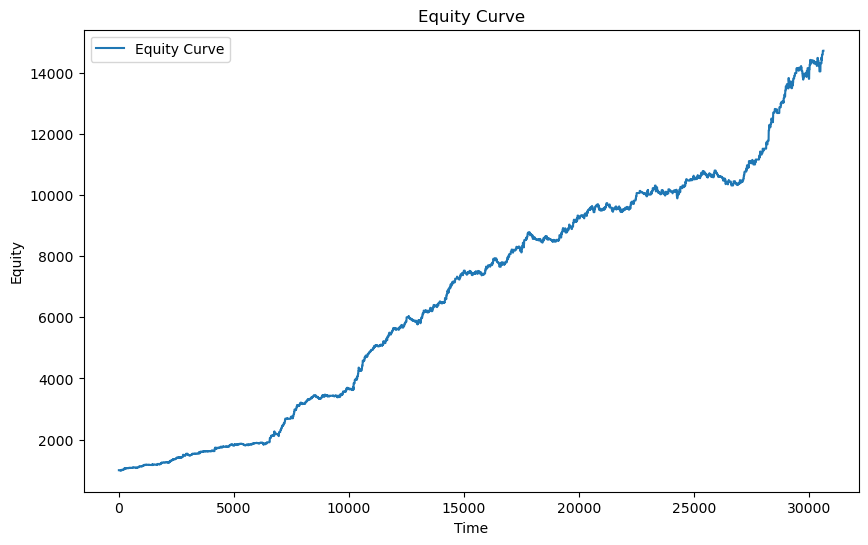

In [165]:
equity_curve = strategy.equity_curve
fig = plt.figure(figsize=(10, 6))
plt.plot(equity_curve, label='Equity Curve')
plt.xlabel('Time')
plt.ylabel('Equity')
plt.title('Equity Curve')
plt.legend()
plt.show()